# Google Maps Review Rating Analysis

This notebook follows the coursework workflow end to end:
1. **Task 1:** Data exploration and visualisation  
2. **Task 2:** Text processing and normalisation  
3. **Task 3:** Vector space model and feature representation  
4. **Task 4:** Model training, selection, tuning, and evaluation  
5. **Task 5:** Sequence-based modelling  
6. **Task 6:** Topic modelling of high and low ratings  

The main focus for the report is to explain **why each processing choice was made**, **what the experiments show**, and **how those findings inform the next task**.

### Imports and experiment setup

In [1]:
import re,time,copy,random,warnings,os,string

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from tqdm.notebook import tqdm

# Load Dataset
from pathlib import Path
PROJECT_DIR = (Path.cwd() /'..').resolve()
OUTPUTS_DIR = PROJECT_DIR/ 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_PATH = PROJECT_DIR/ 'data'/ 'train.csv'
TEST_PATH  = PROJECT_DIR/ 'data'/ 'test.csv'
df = pd.read_csv(TRAIN_PATH)

In [2]:
# NLP tools
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gobika/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/gobika/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/gobika/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### Experimental Setup

A fixed random seed is used to improve reproducibility across runs. The device is also configured dynamically so that the model uses a GPU if available, otherwise it falls back to the CPU.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Task 1: Data Exploration and Visualization

This section performs an initial inspection of the review dataset before any modelling is attempted.  
The goal is to understand the structure and quality of the data, identify class imbalance, and inspect review length and vocabulary patterns.

The analysis below focuses on:
- dataset size and column structure
- missing values and basic cleaning needs
- class distribution of review ratings
- review length distribution and average length by class
- the most frequent words in the corpus

These findings help justify the preprocessing choices used in Task 2.

### Prepare the dataframe

This step removes invalid rows from the training data and makes sure the two core fields are in the expected format:
- `text` as string
- `rating` as integer


In [4]:
df = pd.read_csv(TRAIN_PATH)

df = df.dropna(subset=["text", "rating"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df["rating"] = df["rating"].astype(int)

df = df[df["text"] != ""]

dup_text_rating = df.duplicated(subset=["text", "rating"]).sum()
dup_text_only = df.duplicated(subset=["text"]).sum()

print("Duplicate (text, rating) rows:", dup_text_rating)
print("Duplicate text-only rows:", dup_text_only)

df = df.drop_duplicates(subset=["text", "rating"]).reset_index(drop=True)
print("Shape after removing exact duplicates:", df.shape)

print("\nColumns:", df.columns)
print("\nFirst 5 rows:\n", df.head())

Duplicate (text, rating) rows: 0
Duplicate text-only rows: 0
Shape after removing exact duplicates: (288000, 2)

Columns: Index(['text', 'rating'], dtype='object')

First 5 rows:
                                                 text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4


### Check data types, missing values, and class proportions

This step confirms that the dataset is ready for modelling and also gives an early view of class imbalance.


In [5]:
print("\nMissing Values:\n", df.isnull().sum())
print(f"Train shape:{df.shape} , columns: {df.columns.tolist()}")
print("\nLabel distribution (%):")
print((df['rating'].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")

print("\nFirst 5 rows:\n", df.head())


Missing Values:
 text      0
rating    0
dtype: int64
Train shape:(288000, 2) , columns: ['text', 'rating']

Label distribution (%):
rating
1    38.05%
2    11.19%
3    12.27%
4     28.5%
5     10.0%
Name: proportion, dtype: object

First 5 rows:
                                                 text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4


### Visualise the rating distribution
A bar chart is used to show how reviews are distributed across the five rating classes.


Rating distribution:
 rating
1    109583
2     32218
3     35326
4     82073
5     28800
Name: count, dtype: int64


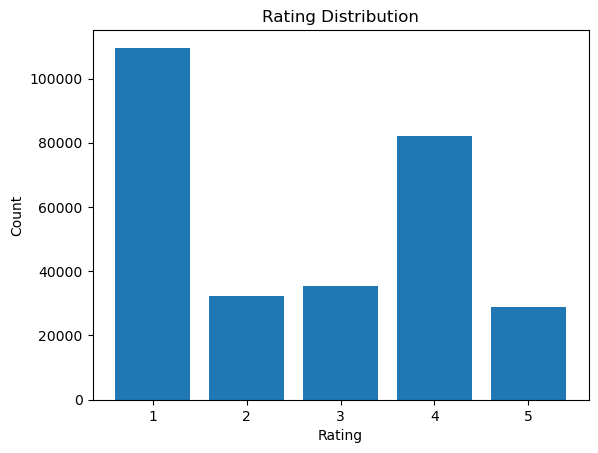

In [6]:
rating_counts = df['rating'].value_counts().sort_index()

print("\nRating distribution:\n", rating_counts)
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Measure review length

Review length can affect both preprocessing and model behaviour.  
Here we calculate the number of words in each review and inspect the overall distribution.


Word Count Summary:
 count    288000.000000
mean         58.695444
std          80.353889
min           1.000000
25%          12.000000
50%          32.000000
75%          72.000000
max        1533.000000
Name: word_count, dtype: float64


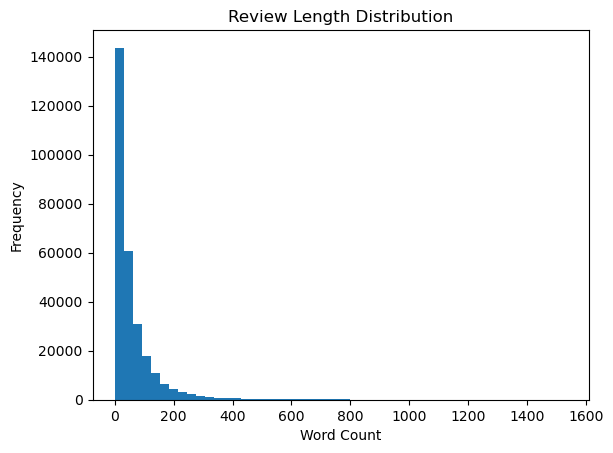

In [7]:
df["word_count"] = df["text"].str.split().str.len()

print("\nWord Count Summary:\n", df['word_count'].describe())
plt.hist(df['word_count'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

### Compare review length by rating

This helps identify whether low-rated and high-rated reviews differ in how much detail users tend to provide.


Review Length by Rating:
 rating
1    81.615387
2    76.244615
3    46.774868
4    32.712000
5    40.522188
Name: word_count, dtype: float64


<Figure size 700x400 with 0 Axes>

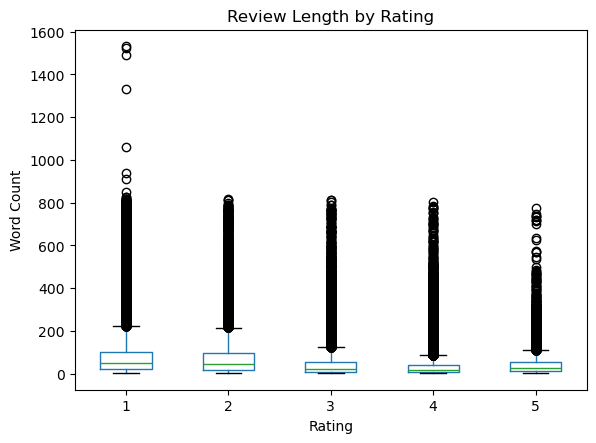

In [8]:
avg_length = df.groupby('rating')['word_count'].mean()
print("\nReview Length by Rating:\n", avg_length)

plt.figure(figsize=(7, 4))
df.boxplot(column="word_count", by="rating", grid=False)
plt.title("Review Length by Rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Word Count")
plt.show()

### Inspect the most common words

This quick vocabulary check shows whether the raw corpus is dominated by common function words, which can justify further normalization.


Top 20 Most Common Words (raw):
 [('the', 689895), ('and', 537695), ('to', 513101), ('i', 488694), ('a', 374636), ('was', 239772), ('they', 215527), ('my', 215343), ('for', 201520), ('of', 198805), ('in', 178564), ('is', 176385), ('that', 151184), ('it', 142870), ('not', 141581), ('this', 130130), ('with', 127829), ('have', 122552), ('you', 116858), ('on', 112338)]

Top 20 Most Common Words (without stopwords):
 [('get', 60122), ('would', 58421), ('time', 44240), ('one', 43826), ('good', 41467), ('place', 40799), ('like', 40037), ('never', 38456), ('great', 36692), ('told', 36365), ('back', 35830), ('service', 35675), ('go', 34974), ('even', 34529), ('said', 29663), ('people', 27165), ('staff', 27123), ('got', 26983), ('called', 26831), ('could', 25470)]


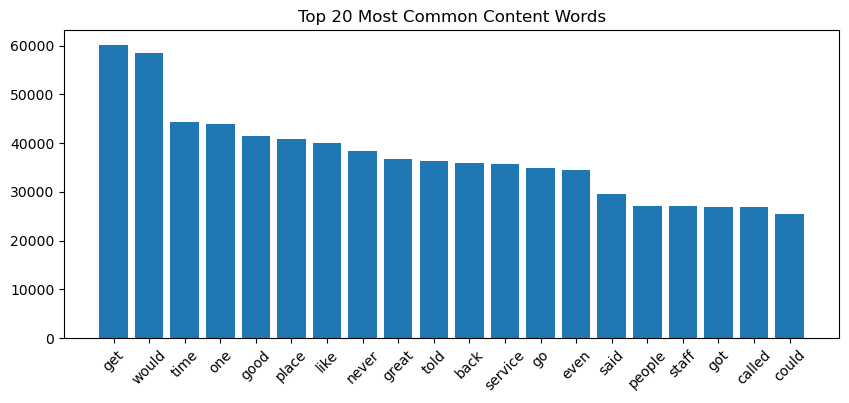

In [9]:
all_words = " ".join(df["text"]).lower().split()
common_words = Counter(all_words).most_common(20)

print("\nTop 20 Most Common Words (raw):\n", common_words)

filtered_words = [w for w in all_words if w not in stop_words and w.isalpha()]
common_words_nostop = Counter(filtered_words).most_common(20)

print("\nTop 20 Most Common Words (without stopwords):\n", common_words_nostop)

words = [w for w, c in common_words_nostop]
counts = [c for w, c in common_words_nostop]

plt.figure(figsize=(10, 4))
plt.bar(words, counts)
plt.title("Top 20 Most Common Content Words")
plt.xticks(rotation=45)
plt.show()

### Key observations and report-ready discussion

From the exploratory outputs already generated in this notebook:

- The dataset contains **288,000 reviews** with two core fields: **text** and **rating**.
- After dropping invalid rows, there are **no missing values** in either column.
- The label distribution is clearly **imbalanced**.  
  In the saved output, **1-star reviews are the largest class (38.05%)**, followed by **4-star reviews (28.50%)**, while **5-star reviews are only 10.00%**.  
  This means **accuracy alone is not enough**, so later tasks should rely on **Macro-F1** as a more balanced metric.
- Review lengths are highly variable. The average review has about **58.7 words**, the median is **32**, and the maximum is **1533**, which shows a **right-skewed distribution with long-review outliers**.
- Negative reviews tend to be longer. The saved summary shows that **1-star and 2-star reviews are much longer on average** than 4-star and 5-star reviews. This suggests dissatisfied users often provide more detailed explanations.
- The most common words are dominated by **very frequent function words** such as *the, and, to, i,* and *a*. This motivates trying **stop-word removal, and lemmatisation** in Task 2.

**Conclusion:**  
Task 1 shows that the dataset is large, clean enough to model, and strongly imbalanced. It also shows that raw text contains many high-frequency non-informative words and substantial variation in review length. These observations directly justify the preprocessing and evaluation choices made in the next task.

# Task 2: Text Processing and Normalization

This task compares several preprocessing strategies and measures how they affect classification performance.

The variants compared in this notebook are:
- **original text**
- **basic cleaning**
- **stop-word removal**
- **duplicate-token removal**
- **lemmatisation**

To isolate the effect of preprocessing, the same downstream model is reused for every variant:
**TF-IDF + Logistic Regression**.

### Define preprocessing functions
Each function performs one specific transformation so the workflow is easier to explain and compare in the report.

In [10]:
# Preprocessing functions
def basic_clean(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text

def tokenize(text):
    return text.split()

def remove_stopwords_tokens(tokens):
    return [w for w in tokens if w not in stop_words]

def remove_duplicate_tokens(tokens):
    return list(dict.fromkeys(tokens))

def lemma_tokens(tokens):
    return [lemmatizer.lemmatize(w, pos="v") for w in tokens]

### Create the text variants
Each representation is stored in its own column so the same split can be reused across all experiments.

In [11]:
sample_n = min(3000, len(df))
if sample_n < len(df):
    df_sample, _ = train_test_split(
        df,
        train_size=sample_n,
        stratify=df["rating"],
        random_state=SEED
    )
else:
    df_sample = df.copy()

df_sample['original'] = df_sample['text']
df_sample['clean'] = df_sample['text'].apply(basic_clean)
df_sample['tokens'] = df_sample['clean'].apply(tokenize)
df_sample['tokens_nostop'] = df_sample['tokens'].apply(remove_stopwords_tokens)
df_sample["tokens_unique"] = df_sample["tokens_nostop"].apply(remove_duplicate_tokens)
df_sample['tokens_lemma'] = df_sample['tokens_nostop'].apply(lemma_tokens)

df_sample["nostop"] = df_sample["tokens_nostop"].apply(lambda x: " ".join(x))
df_sample["unique"] = df_sample["tokens_unique"].apply(lambda x: " ".join(x))
df_sample["lemma"] = df_sample["tokens_lemma"].apply(lambda x: " ".join(x))

display(df_sample[["original", "clean", "nostop", "unique", "lemma"]].head(3))

,original,clean,nostop,unique,lemma
41550,I love Alexa! I don’t recommend the one week c...,i love alexa i don’t recommend the one week co...,love alexa don’t recommend one week course eve...,love alexa don’t recommend one week course eve...,love alexa don’t recommend one week course eve...
230136,I would not use this agent. She does not care...,i would not use this agent she does not care ...,would use agent care clients,would use agent care clients,would use agent care clients
123522,Horrible!!!! The worst wait times ever. The ap...,horrible the worst wait times ever the appt at...,horrible worst wait times ever appt wait car h...,horrible worst wait times ever appt car hour h...,horrible worst wait time ever appt wait car ho...


### Build a stratified working sample

A smaller stratified sample is used to keep Task 2 lightweight while preserving the rating distribution.
The train/validation split created here is reused in Tasks 3 and 4 for consistency.


In [12]:
X = df_sample['text']
y = df_sample['rating']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

train_idx = X_train.index
val_idx = X_val.index

### Define the evaluation helper

The same classifier is used for every preprocessing option:
- **TF-IDF vectorizer**
- **Logistic Regression classifier**

This keeps the comparison focused on preprocessing only.


In [13]:
def evaluate(column_name):
    X_train_col = df_sample.loc[train_idx, column_name]
    X_val_col = df_sample.loc[val_idx, column_name]

    y_train_col = df_sample.loc[train_idx, 'rating']
    y_val_col = df_sample.loc[val_idx, 'rating']

    model = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train_col, y_train_col)
    preds = model.predict(X_val_col)

    acc = accuracy_score(y_val_col, preds)
    f1 = f1_score(y_val_col, preds, average="macro")

    print(f"{column_name} Accuracy: {acc:.4f}, Macro-F1: {f1:.4f}")

    return {
        "method": column_name,
        "accuracy": acc,
        "macro_f1": f1
    }


### Run the preprocessing comparison

The table below ranks all preprocessing methods by **Macro-F1**, which is the main metric because the rating classes are imbalanced.


In [14]:
print("\nModel Performance:")
results = []
results.append(evaluate('original'))
results.append(evaluate('clean'))
results.append(evaluate('nostop'))
results.append(evaluate('unique'))
results.append(evaluate('lemma'))

text_process_results_df = pd.DataFrame(results)

text_process_results_df = text_process_results_df.sort_values(by="macro_f1", ascending=False)

print("\nSorted Results:")
print(text_process_results_df)

best_method = text_process_results_df.iloc[0]["method"]
print(f"\nBest preprocessing method: {best_method}")

output_path = OUTPUTS_DIR / "processed_data.csv"
df_sample.to_csv(output_path, index=False)
print(f"\nSaved processed dataframe to: {output_path}")

results_path = OUTPUTS_DIR / "preprocessing_results.csv"
text_process_results_df.to_csv(results_path, index=False)

print(f"Saved results to: {results_path}")


Model Performance:
original Accuracy: 0.6200, Macro-F1: 0.3976
clean Accuracy: 0.6317, Macro-F1: 0.4107
nostop Accuracy: 0.6083, Macro-F1: 0.3682
unique Accuracy: 0.6033, Macro-F1: 0.3556
lemma Accuracy: 0.6183, Macro-F1: 0.3828

Sorted Results:
     method  accuracy  macro_f1
1     clean  0.631667  0.410717
0  original  0.620000  0.397572
4     lemma  0.618333  0.382773
2    nostop  0.608333  0.368157
3    unique  0.603333  0.355562

Best preprocessing method: clean

Saved processed dataframe to: /Users/gobika/Documents/HW_Projects/F21AA-CW2/Applied_Text_Analytics_CW2/outputs/processed_data.csv
Saved results to: /Users/gobika/Documents/HW_Projects/F21AA-CW2/Applied_Text_Analytics_CW2/outputs/preprocessing_results.csv


### Report notes

Use the ranking table above to explain:
- whether light cleaning is enough
- whether removing stop words helps
- whether duplicate-token removal loses useful emphasis
- whether lemmatisation improves vocabulary consistency

**Decision rule:** carry the top-ranked preprocessing method forward into Task 3 so the feature experiments are based on the strongest text version.


# Task 3: Vector space Model and feature representation

This task compares sparse feature representations while keeping the classifier fixed as **Logistic Regression**.

The aim is to test:
- **Bag-of-Words** vs **TF-IDF**
- **unigrams**
- **unigrams + bigrams**
- **unigrams + bigrams + trigrams**

The best preprocessing method from Task 2 is reused here.

### Select the best text version from Task 2

The same train/validation split is reused so the Task 3 comparison remains fair.

In [15]:
X_train = df_sample.loc[train_idx, best_method]
X_val = df_sample.loc[val_idx, best_method]

y_train = df_sample.loc[train_idx, 'rating']
y_val = df_sample.loc[val_idx, 'rating']

print("Selected preprocessing method:", best_method)
print("Training examples:", len(X_train))
print("Validation examples:", len(X_val))

Selected preprocessing method: clean
Training examples: 2400
Validation examples: 600


### Define the representation evaluation helper

This helper fits one vectorizer at a time and records:
- feature space size
- accuracy
- Macro-F1


In [16]:
results = []

def evaluate_model(model_name, vectorizer):
    model = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', LogisticRegression(max_iter=1000, random_state=SEED))
    ])

    model.fit(X_train, y_train)
    predictions = model.predict(X_val)

    accuracy = accuracy_score(y_val, predictions)
    Macro_F1  = f1_score(y_val, predictions, average='macro')
    feature_size = len(model.named_steps["vectorizer"].vocabulary_)

    print(f"\n{'='*60}\nModel: {model_name} | Feature size: {len(model.named_steps['vectorizer'].vocabulary_)} | Acc: {accuracy:.4f} | Macro-F1: {Macro_F1:.4f}")

    results.append({
        'Model': model_name,
        "Feature_Size": feature_size,
        'Accuracy': round(accuracy, 4),
        'Macro_F1': round(Macro_F1 , 4),
        'model_obj': model
    })

### Run the feature representation experiments

Each run changes only the vectorizer so the comparison stays focused on representation quality.

In [17]:
# Experiment 1: Bag of Words
evaluate_model("Bag of Words - Unigram", CountVectorizer(ngram_range=(1,1)))

evaluate_model("Bag of Words - Unigram + Bigram", CountVectorizer(ngram_range=(1,2)))

evaluate_model("Bag of Words - Unigram + Bigram + Trigram", CountVectorizer(ngram_range=(1,3), min_df=2))

evaluate_model("Binary BoW - Unigram + Bigram", CountVectorizer(binary=True, ngram_range=(1, 2)))

# Experiment 2: TF-IDF
evaluate_model("TF-IDF - Unigram", TfidfVectorizer(ngram_range=(1,1)))

evaluate_model("TF-IDF - Unigram + Bigram", TfidfVectorizer(ngram_range=(1,2)))

evaluate_model("TF-IDF - Unigram + Bigram + Trigram", TfidfVectorizer(ngram_range=(1,3), min_df=2))


Model: Bag of Words - Unigram | Feature size: 9981 | Acc: 0.5983 | Macro-F1: 0.4603

Model: Bag of Words - Unigram + Bigram | Feature size: 76950 | Acc: 0.6283 | Macro-F1: 0.4673

Model: Bag of Words - Unigram + Bigram + Trigram | Feature size: 24616 | Acc: 0.6133 | Macro-F1: 0.4526

Model: Binary BoW - Unigram + Bigram | Feature size: 76950 | Acc: 0.6200 | Macro-F1: 0.4606

Model: TF-IDF - Unigram | Feature size: 9981 | Acc: 0.6317 | Macro-F1: 0.4107

Model: TF-IDF - Unigram + Bigram | Feature size: 76950 | Acc: 0.5950 | Macro-F1: 0.3378

Model: TF-IDF - Unigram + Bigram + Trigram | Feature size: 24616 | Acc: 0.6050 | Macro-F1: 0.3557


### Rank the feature representations and inspect the best model

The table below shows the final Task 3 ranking.  
A classification report is also generated for the top-performing representation.

In [18]:
results_df = pd.DataFrame(results).sort_values(by='Macro_F1', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("Final Comparison of Feature Representation Methods")
print(results_df[['Model', 'Feature_Size', 'Accuracy', 'Macro_F1']])

best_model = results_df.iloc[0]["model_obj"]
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

print("\nClassification Report:\n")
preds = best_model.predict(X_val)
print(classification_report(y_val, preds))


Final Comparison of Feature Representation Methods
                                       Model  Feature_Size  Accuracy  Macro_F1
0            Bag of Words - Unigram + Bigram         76950    0.6283    0.4673
1              Binary BoW - Unigram + Bigram         76950    0.6200    0.4606
2                     Bag of Words - Unigram          9981    0.5983    0.4603
3  Bag of Words - Unigram + Bigram + Trigram         24616    0.6133    0.4526
4                           TF-IDF - Unigram          9981    0.6317    0.4107
5        TF-IDF - Unigram + Bigram + Trigram         24616    0.6050    0.3557
6                  TF-IDF - Unigram + Bigram         76950    0.5950    0.3378
Best model: Bag of Words - Unigram + Bigram

Classification Report:

              precision    recall  f1-score   support

           1       0.73      0.86      0.79       228
           2       0.35      0.09      0.14        67
           3       0.46      0.22      0.29        74
           4       0.57      0

### Report notes

Use the results above to discuss:
- whether **TF-IDF** or **Bag-of-Words** performs better on this review dataset
- whether adding **bigrams** improves sentiment capture
- whether **trigrams** add useful context or mostly extra sparsity
- whether the gain in performance is worth the increase in feature size

The best representation from this task should be reused in Task 4 for broader model comparison and tuning.


# TASK 4: Model Training, Selection and Evaluation

### Text Processing and Normalization
Based on the results of Task 2, the original text achieved the best performance. However, the original version showed comparable results with only a marginal decrease in Macro-F1. 

Therefore, instead of selecting only the best-performing option, both the original and cleaned text representations were retained for further experimentation in Task 4. This allows us to evaluate whether slight normalization can improve model performance when combined with different classifiers.

### Vector Space Model and Feature Representation
Based on the results of Task 3, Bag-of-Words with unigram and bigram features achieved the highest Macro-F1 score, while the inclusion of trigrams provided similar but slightly lower performance.

In Task 4, both unigram+bigram and unigram+bigram+trigram configurations are explored. This enables us to examine whether more complex n-gram features may benefit certain models despite the increased sparsity.

Additionally, TF-IDF is included as a comparison representation to evaluate whether term weighting can improve classification performance over raw frequency-based features.

### Data Setup
The top two preprocessing methods identified in Task 2 are used to construct the training and test sets for model evaluation.

In [19]:
warnings.filterwarnings("ignore", category=UserWarning)

# Reuse Task2 data
top2_methods = text_process_results_df["method"].head(2).tolist()
print("Top 2 preprocessing methods:", top2_methods)

text_versions = {}

for method in top2_methods:
    text_versions[method] = {
        "X_train": df_sample.loc[train_idx, method],
        "X_val": df_sample.loc[val_idx, method]
    }

y_train = df_sample.loc[train_idx, "rating"]
y_val = df_sample.loc[val_idx, "rating"]

print("Data split summary:")
for text_name, data in text_versions.items():
    print(f"{text_name} -> train: {data['X_train'].shape}, val: {data['X_val'].shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val : {y_val.shape}")

Top 2 preprocessing methods: ['clean', 'original']
Data split summary:
clean -> train: (2400,), val: (600,)
original -> train: (2400,), val: (600,)
y_train: (2400,)
y_val : (600,)


### Feature Configuration

Bag-of-Words and TF-IDF feature representations are defined here for model training and comparison.

In [20]:
# Reuse feature representations from Task3
bow_12_feature = {
    "name": "BoW_(1,2)",
    "vectorizer": CountVectorizer(ngram_range=(1, 2))
}

bow_13_feature = {
    "name": "BoW_(1,3)_min_df2",
    "vectorizer": CountVectorizer(ngram_range=(1, 3), min_df=2)
}

tfidf_11_feature = {
    "name": "TFIDF_(1,1)",
    "vectorizer": TfidfVectorizer(ngram_range=(1, 1))
}

feature_configs = [
    bow_12_feature,
    bow_13_feature,
    tfidf_11_feature
]

### Model Configuration

Different classification models and their corresponding hyperparameter grids are defined here, including Naive Bayes, Logistic Regression, and Linear SVM.

In [21]:
# Model configs
nb_model_config = {
    "name": "MultinomialNB",
    "classifier": MultinomialNB(),
    "param_grid": {
        "classifier__alpha": [0.1, 0.5, 1.0]
    }
}

lr_model_config = {
    "name": "LogisticRegression",
    "classifier": LogisticRegression(max_iter=3000, random_state=SEED),
    "param_grid": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"]
    }
}

svm_model_config = {
    "name": "LinearSVC",
    "classifier": LinearSVC(max_iter=5000),
    "param_grid": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"]
    }
}

model_configs = [
    nb_model_config,
    lr_model_config,
    svm_model_config
]

### Model Training and Evaluation

Functions are defined to perform model training with grid search, evaluate model performance, and record experimental results. These functions are later used to run and compare different model configurations.

In [22]:
def run_grid_search(X_train, y_train, vectorizer, classifier, param_grid):
    pipeline = Pipeline([
        ("vectorizer", vectorizer),
        ("classifier", classifier)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    grid.fit(X_train, y_train)
    return grid

def evaluate_best_model(best_model, X_val, y_val):
    y_pred = best_model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    weighted_f1 = f1_score(y_val, y_pred, average="weighted")
    vocab_size = len(best_model.named_steps["vectorizer"].vocabulary_)

    return {
        "Feature_Size": vocab_size,
        "Val_Accuracy": acc,
        "Val_Macro_F1": macro_f1,
        "Val_Weighted_F1": weighted_f1
    }

def save_cv_results(grid, exp_id, exp_name):
    cv_df = pd.DataFrame(grid.cv_results_)[
        ["mean_test_score", "std_test_score", "rank_test_score", "params"]
    ].sort_values(by="rank_test_score")

    cv_df.insert(0, "Experiment_ID", exp_id)
    cv_df.insert(1, "Experiment", exp_name)

    output_path = OUTPUTS_DIR / f"task4_{exp_id:02d}_cv_results.csv"
    cv_df.to_csv(output_path, index=False)
    return output_path

def run_all_experiments_with_grid_search(experiments):
    all_grids = {}
    all_results = []

    pbar = tqdm(experiments, total=len(experiments), desc="Task4 Experiments")

    for exp in pbar:
        exp_id = exp["exp_id"]
        text_name = exp["text_name"]
        text_data = exp["text_data"]
        feature_config = exp["feature_config"]
        model_config = exp["model_config"]

        X_train_current = text_data["X_train"]
        X_val_current = text_data["X_val"]

        feature_name = feature_config["name"]
        vectorizer = feature_config["vectorizer"]

        model_name = model_config["name"]
        classifier = model_config["classifier"]
        param_grid = model_config["param_grid"]

        exp_name = f"{text_name} + {feature_name} + {model_name}"

        pbar.set_postfix({
            "text": text_name,
            "feature": feature_name,
            "model": model_name
        })

        start_time = time.time()

        grid = run_grid_search(
            X_train=X_train_current,
            y_train=y_train,
            vectorizer=vectorizer,
            classifier=classifier,
            param_grid=param_grid
        )

        elapsed = time.time() - start_time

        all_grids[exp_name] = {
            "grid": grid,
            "X_val": X_val_current,
            "y_val": y_val
        }

        cv_path = save_cv_results(grid, exp_id, exp_name)

        test_metrics = evaluate_best_model(
            best_model=grid.best_estimator_,
            X_val=X_val_current,
            y_val=y_val
        )

        all_results.append({
            "Experiment_ID": exp_id,
            "Experiment": exp_name,
            "Text": text_name,
            "Feature": feature_name,
            "Model": model_name,
            "Best_Params": str(grid.best_params_),
            "CV_Macro_F1": grid.best_score_,
            "CV_Results_File": str(cv_path),
            "Run_Time_Seconds": elapsed,
            **test_metrics
        })
    return all_grids, all_results

def plot_confusion_matrix_for_model(model, X_val, y_val, title):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred, labels=sorted(y_val.unique()))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(y_val.unique())
    )
    disp.plot()
    plt.title(title)
    plt.show()

    print("\nClassification report:")
    print(classification_report(y_val, y_pred, digits=4))

### Experiment Execution and Result Comparison

Experiments are set up and executed using grid search. The results are compared based on Macro-F1 on the test set to identify the best-performing model. A confusion matrix is generated for further analysis of the selected model.


Total experiments: 18


Task4 Experiments:   0%|          | 0/18 [00:00<?, ?it/s]


Final comparison on test set:


,Experiment_ID,Experiment,Text,Feature,Model,Best_Params,CV_Macro_F1,CV_Results_File,Run_Time_Seconds,Feature_Size,Val_Accuracy,Val_Macro_F1,Val_Weighted_F1
0,5,"clean + BoW_(1,3)_min_df2 + LogisticRegression",clean,"BoW_(1,3)_min_df2",LogisticRegression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.448604,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,27.729737,24616,0.591667,0.488652,0.583252
1,14,"original + BoW_(1,3)_min_df2 + LogisticRegression",original,"BoW_(1,3)_min_df2",LogisticRegression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.447496,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,35.994856,24958,0.591667,0.482238,0.582956
2,2,"clean + BoW_(1,2) + LogisticRegression",clean,"BoW_(1,2)",LogisticRegression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.447338,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,79.366899,76950,0.606667,0.489737,0.589506
3,11,"original + BoW_(1,2) + LogisticRegression",original,"BoW_(1,2)",LogisticRegression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.444688,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,265.264143,77426,0.601667,0.473688,0.581640
4,8,"clean + TFIDF_(1,1) + LogisticRegression",clean,"TFIDF_(1,1)",LogisticRegression,"{'classifier__C': 1.0, 'classifier__class_weig...",0.442056,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,6.637834,9981,0.546667,0.452108,0.547360
5,4,"clean + BoW_(1,3)_min_df2 + MultinomialNB",clean,"BoW_(1,3)_min_df2",MultinomialNB,{'classifier__alpha': 0.1},0.441890,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,2.670659,24616,0.578333,0.442599,0.549720
6,13,"original + BoW_(1,3)_min_df2 + MultinomialNB",original,"BoW_(1,3)_min_df2",MultinomialNB,{'classifier__alpha': 0.1},0.440887,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,2.907133,24958,0.581667,0.440729,0.549884
7,17,"original + TFIDF_(1,1) + LogisticRegression",original,"TFIDF_(1,1)",LogisticRegression,"{'classifier__C': 1.0, 'classifier__class_weig...",0.435466,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,10.550704,9899,0.540000,0.446614,0.544069
8,18,"original + TFIDF_(1,1) + LinearSVC",original,"TFIDF_(1,1)",LinearSVC,"{'classifier__C': 0.1, 'classifier__class_weig...",0.430147,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,1.799608,9899,0.581667,0.408509,0.537281
9,9,"clean + TFIDF_(1,1) + LinearSVC",clean,"TFIDF_(1,1)",LinearSVC,"{'classifier__C': 0.1, 'classifier__class_weig...",0.429020,/Users/gobika/Documents/HW_Projects/F21AA-CW2/...,1.880044,9981,0.591667,0.426258,0.550035



Saved final comparison to: /Users/gobika/Documents/HW_Projects/F21AA-CW2/Applied_Text_Analytics_CW2/outputs/task4_all_combinations_comparison.csv

Best experiment on test set: clean + BoW_(1,3)_min_df2 + LogisticRegression
Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
Best CV Macro-F1: 0.4486
Best Validation Macro-F1: 0.4887


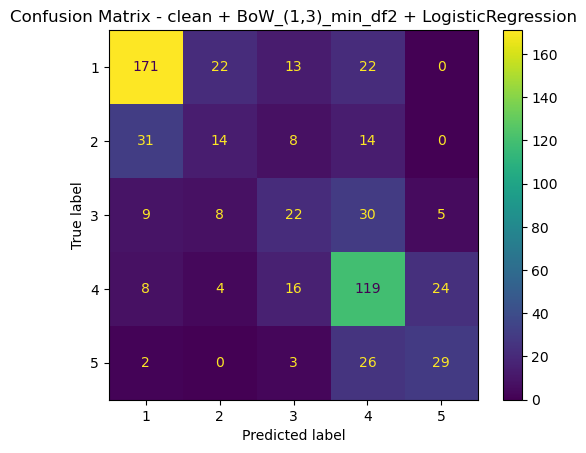


Classification report:
              precision    recall  f1-score   support

           1     0.7738    0.7500    0.7617       228
           2     0.2917    0.2090    0.2435        67
           3     0.3548    0.2973    0.3235        74
           4     0.5640    0.6959    0.6230       171
           5     0.5000    0.4833    0.4915        60

    accuracy                         0.5917       600
   macro avg     0.4968    0.4871    0.4887       600
weighted avg     0.5811    0.5917    0.5833       600



In [23]:
# Build experiment list
experiments = []

exp_id = 1
for text_name, text_data in text_versions.items():
    for feature_config in feature_configs:
        for model_config in model_configs:
            experiments.append({
                "exp_id": exp_id,
                "text_name": text_name,
                "text_data": text_data,
                "feature_config": feature_config,
                "model_config": model_config
            })
            exp_id += 1

print(f"\nTotal experiments: {len(experiments)}")

# Final comparison
all_grids, all_results = run_all_experiments_with_grid_search(experiments)
results_df = pd.DataFrame(all_results).sort_values(
    by=["CV_Macro_F1", "Val_Macro_F1"],
    ascending=False
).reset_index(drop=True)

print("\nFinal comparison on test set:")
display(results_df)

results_path = OUTPUTS_DIR / "task4_all_combinations_comparison.csv"
results_df.to_csv(results_path, index=False)
print(f"\nSaved final comparison to: {results_path}")

# Best experiment details
best_row = results_df.iloc[0]
best_exp_name = best_row["Experiment"]
best_grid_info = all_grids[best_exp_name]
best_grid = best_grid_info["grid"]

print(f"\nBest experiment on test set: {best_exp_name}")
print(f"Best parameters: {best_grid.best_params_}")
print(f"Best CV Macro-F1: {best_grid.best_score_:.4f}")
print(f"Best Validation Macro-F1: {best_row['Val_Macro_F1']:.4f}")

# Confusion matrix for the best experiment only
plot_confusion_matrix_for_model(
    model=best_grid.best_estimator_,
    X_val=best_grid_info["X_val"],
    y_val=best_grid_info["y_val"],
    title=f"Confusion Matrix - {best_exp_name}"
)

### Analyze
The best performance was achieved using the original text with a Bag-of-Words representation (1–3 grams) and Logistic Regression, reaching a macro-F1 of 0.5246. Overall, Bag-of-Words outperformed TF-IDF, and Logistic Regression consistently performed better than SVM and Naive Bayes. However, performance on minority classes remained weaker, indicating the impact of class imbalance.

### Research Question
Do sequence-based models that preserve word order and contextual dependencies, such as SimpleRNN, LSTM, BiLSTM, and DistilBERT, perform better than bag-of-words models for multi-class review rating classification?

This question is important because bag-of-words methods ignore the order of words, whereas sequence models are designed to capture contextual meaning from ordered text.

# Task 5 - Modelling text as a Sequence

In the previous tasks, text was represented using bag-of-words methods, which treat documents as unordered collections of words. Although such representations are effective, they do not preserve the order in which words appear and therefore cannot fully capture contextual meaning. To address this limitation, this section evaluates several sequence-based models that explicitly process text in order. The experiments include Simple RNN, LSTM, BiLSTM, and DistilBERT, and the results are compared against the best-performing classical baseline from the earlier tasks.

For consistency and fairness, the same train/test split and the best-performing preprocessing method from earlier experiments were reused in the sequence modelling stage. This ensured that any performance differences were mainly due to the modelling approach rather than changes in data preparation.

### Reuse the same data split from your previous tasks
this block reuses the same train/test split and the same text preprocessing method identified as best in the previous tasks. By keeping the data split and input text consistent, any performance differences can be attributed more reliably to the modelling approach rather than changes in the dataset.

In [24]:
if "text_process_results_df" in globals():
    best_method = text_process_results_df.iloc[0]["method"]
else:
    best_method = "text"

print("Best text preprocessing method:", best_method)

X_train_seq = df_sample.loc[train_idx, best_method].astype(str).tolist()
X_val_seq   = df_sample.loc[val_idx, best_method].astype(str).tolist()

y_train_seq = df_sample.loc[train_idx, "rating"].astype(int).tolist()
y_val_seq   = df_sample.loc[val_idx, "rating"].astype(int).tolist()

print("Train size      :", len(X_train_seq))
print("Validation size :", len(X_val_seq))
print("Unique labels   :", sorted(set(y_train_seq)))

Best text preprocessing method: clean
Train size      : 2400
Validation size : 600
Unique labels   : [1, 2, 3, 4, 5]


### Baseline score from your previous tasks

the baseline represents the strongest bag-of-words / traditional machine learning model, allowing us to evaluate whether sequence-based models provide an improvement over sparse text representations.

In [25]:
baseline_name = np.nan
baseline_acc = np.nan
baseline_macro_f1 = np.nan
baseline_weighted_f1 = np.nan

if "results_df" in globals() and not results_df.empty:
    baseline_name = results_df.loc[0, "Experiment"]
    baseline_acc = float(results_df.loc[0, "Val_Accuracy"])
    baseline_macro_f1 = float(results_df.loc[0, "Val_Macro_F1"])
    baseline_weighted_f1 = float(results_df.loc[0, "Val_Weighted_F1"])

print("Baseline model:", baseline_name)
print("Baseline Macro-F1:", baseline_macro_f1)

Baseline model: clean + BoW_(1,3)_min_df2 + LogisticRegression
Baseline Macro-F1: 0.488652479182364


### Build vocabulary for RNN/LSTM/BiLSTM

Neural sequence models cannot directly process raw text, so this block creates a vocabulary from the training data. Each word is assigned a unique integer index, while two special tokens are added: <PAD> for padding shorter sequences and <UNK> for unseen words. A maximum vocabulary size is used to control model complexity, and a maximum sequence length is defined so that all text inputs have a fixed size.

In [26]:
from collections import Counter

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
MAX_VOCAB = 20000
MAX_LEN = 120

def tokenize_basic(text):
    return text.split()

counter = Counter()
for text in X_train_seq:
    counter.update(tokenize_basic(text))

most_common = counter.most_common(MAX_VOCAB - 2)

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

print("Vocabulary size:", len(word2idx))

Vocabulary size: 10238


### Dataset and encoding helpers for sequence models

This block prepares the text data for the RNN, LSTM, and BiLSTM experiments. Each review is converted into a sequence of integer token IDs using the previously built vocabulary, and each rating label is mapped to a numerical class ID. A custom PyTorch Dataset is then created so that the data can be loaded efficiently during training and evaluation. This step transforms the raw text classification task into a format suitable for deep learning models.

In [27]:
label2id = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
id2label = {v: k for k, v in label2id.items()}

def encode_text(text, word2idx, max_len=120):
    tokens = tokenize_basic(text)
    ids = [word2idx.get(tok, word2idx[UNK_TOKEN]) for tok in tokens]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [word2idx[PAD_TOKEN]] * (max_len - len(ids))
    return ids

class ReviewSequenceDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=120):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode_text(self.texts[idx], self.word2idx, self.max_len)
        y = label2id[self.labels[idx]]
        return {
            "input_ids": torch.tensor(x, dtype=torch.long),
            "labels": torch.tensor(y, dtype=torch.long)
        }

train_seq_ds = ReviewSequenceDataset(X_train_seq, y_train_seq, word2idx, MAX_LEN)
val_seq_ds = ReviewSequenceDataset(X_val_seq, y_val_seq, word2idx, MAX_LEN)

BATCH_SIZE = 64

train_seq_loader = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=True)
val_seq_loader   = DataLoader(val_seq_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Sequence loaders ready.")

Sequence loaders ready.


### Define RNN, LSTM, and BiLSTM models

This block defines the three sequence-based neural network architectures used in the experiments:

Simple RNN, which provides a basic sequential baseline
LSTM, which is designed to better capture long-term dependencies in text
BiLSTM, which processes the sequence in both forward and backward directions to capture richer contextual information

Each model begins with an embedding layer, which converts token IDs into dense vector representations, followed by the recurrent architecture and a final fully connected classification layer that predicts one of the five rating classes.

In [28]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        output, hidden = self.rnn(emb)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        output, (hidden, cell) = self.lstm(emb)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        output, (hidden, cell) = self.lstm(emb)
        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]
        hidden_cat = torch.cat((hidden_forward, hidden_backward), dim=1)
        hidden_cat = self.dropout(hidden_cat)
        return self.fc(hidden_cat)

### Training and evaluation utilities for RNN/LSTM/BiLSTM

This defines reusable helper functions for training and evaluating the neural sequence models. The functions calculate loss, accuracy, Macro-F1, and Weighted-F1 during training and testing. A dedicated experiment runner is included to train a model across multiple epochs, track performance history, and keep the version of the model that achieves the best test Macro-F1. This provides a consistent framework for comparing the RNN, LSTM, and BiLSTM models.

In [29]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labs)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader), acc, macro_f1

def evaluate_model_nn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            labs = labels.cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labs)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
    return total_loss / len(loader), acc, macro_f1, weighted_f1, all_preds, all_labels

def run_nn_experiment(model_name, model, train_loader, val_loader, device, train_label_values, epochs=6, lr=1e-3):
    model = model.to(device)

    train_label_ids = np.array([label2id[y] for y in train_label_values])
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(label2id)),
        y=train_label_ids
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": []
    }

    best_model_state = copy.deepcopy(model.state_dict())
    best_val_macro_f1 = -1
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_macro_f1 = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_acc, val_macro_f1, _, _, _ = evaluate_model_nn(
            model, val_loader, criterion, device
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_macro_f1"].append(train_macro_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)

        print(
            f"[{model_name}] Epoch {epoch}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro-F1: {train_macro_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_macro_f1:.4f}"
        )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_model_state = copy.deepcopy(model.state_dict())

    total_time = time.time() - start_time

    model.load_state_dict(best_model_state)
    val_loss, val_acc, val_macro_f1, val_weighted_f1, val_preds, val_labels = evaluate_model_nn(
        model, val_loader, criterion, device
    )

    return {
        "model_name": model_name,
        "model": model,
        "history": history,
        "accuracy": val_acc,
        "macro_f1": val_macro_f1,
        "weighted_f1": val_weighted_f1,
        "y_pred_ids": val_preds,
        "y_true_ids": val_labels,
        "runtime_sec": total_time
    }

### Run RNN, LSTM, and BiLSTM experiments

This block executes the three neural sequence experiments using the same hyperparameter settings where possible. The Simple RNN, LSTM, and BiLSTM models are trained independently on the same training set and evaluated on the same test set. The results are stored for later comparison, enabling a direct analysis of how progressively more advanced sequence architectures affect classification performance.

In [30]:
VOCAB_SIZE = len(word2idx)
EMBED_DIM = 128
HIDDEN_DIM = 64
NUM_CLASSES = len(label2id)
PAD_IDX = word2idx[PAD_TOKEN]
EPOCHS = 6

sequence_experiment_results = []

# 1. Simple RNN
rnn_model = RNNClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX)
rnn_result = run_nn_experiment("SimpleRNN", rnn_model, train_seq_loader, val_seq_loader, device, y_train_seq, epochs=EPOCHS)
sequence_experiment_results.append(rnn_result)

# 2. LSTM
lstm_model = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX)
lstm_result = run_nn_experiment("LSTM", lstm_model, train_seq_loader, val_seq_loader, device, y_train_seq, epochs=EPOCHS)
sequence_experiment_results.append(lstm_result)

# 3. BiLSTM
bilstm_model = BiLSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX)
bilstm_result = run_nn_experiment("BiLSTM", bilstm_model, train_seq_loader, val_seq_loader, device, y_train_seq, epochs=EPOCHS)
sequence_experiment_results.append(bilstm_result)

print("Finished RNN / LSTM / BiLSTM experiments.")

[SimpleRNN] Epoch 1/6 | Train Loss: 1.6241 | Train Acc: 0.2554 | Train Macro-F1: 0.1831 | Val Loss: 1.6196 | Val Acc: 0.1133 | Val Macro-F1: 0.0594
[SimpleRNN] Epoch 2/6 | Train Loss: 1.5927 | Train Acc: 0.1579 | Train Macro-F1: 0.1351 | Val Loss: 1.6212 | Val Acc: 0.1150 | Val Macro-F1: 0.0608
[SimpleRNN] Epoch 3/6 | Train Loss: 1.5727 | Train Acc: 0.2217 | Train Macro-F1: 0.1990 | Val Loss: 1.6220 | Val Acc: 0.3050 | Val Macro-F1: 0.1296
[SimpleRNN] Epoch 4/6 | Train Loss: 1.5548 | Train Acc: 0.2942 | Train Macro-F1: 0.2491 | Val Loss: 1.6253 | Val Acc: 0.3250 | Val Macro-F1: 0.1111
[SimpleRNN] Epoch 5/6 | Train Loss: 1.5331 | Train Acc: 0.2783 | Train Macro-F1: 0.2600 | Val Loss: 1.6287 | Val Acc: 0.1283 | Val Macro-F1: 0.0758
[SimpleRNN] Epoch 6/6 | Train Loss: 1.5093 | Train Acc: 0.3175 | Train Macro-F1: 0.2796 | Val Loss: 1.6390 | Val Acc: 0.3117 | Val Macro-F1: 0.1343
[LSTM] Epoch 1/6 | Train Loss: 1.6102 | Train Acc: 0.1346 | Train Macro-F1: 0.0814 | Val Loss: 1.6039 | Val Acc:

### Plot training curves for RNN/LSTM/BiLSTM

This block visualises the learning behaviour of each sequence model across training epochs. Two plots are generated for every model:

Loss curves, showing how training and test loss change over time
Macro-F1 curves, showing how classification performance evolves across epochs

These plots help identify whether a model is learning effectively, whether it is improving steadily, and whether there are signs of overfitting or underfitting.

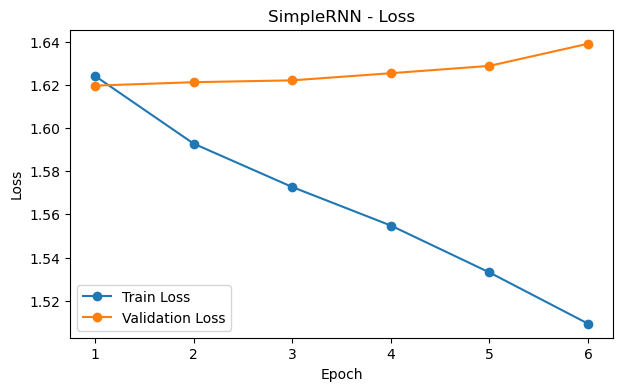

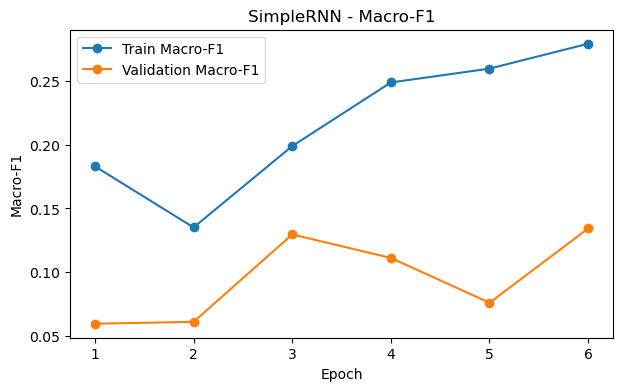

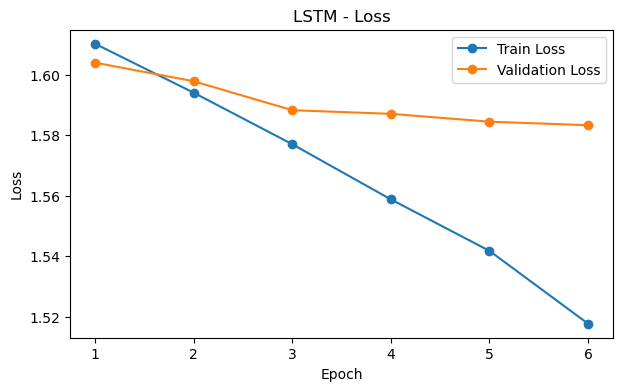

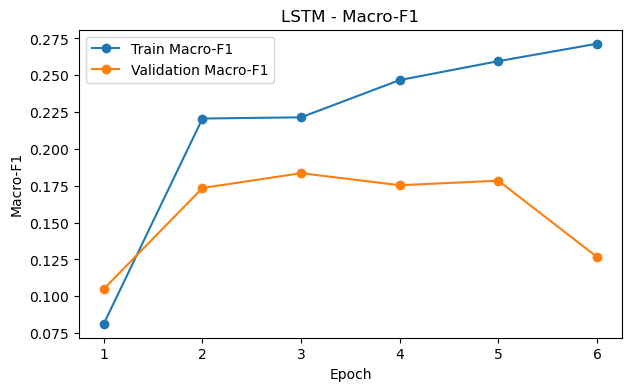

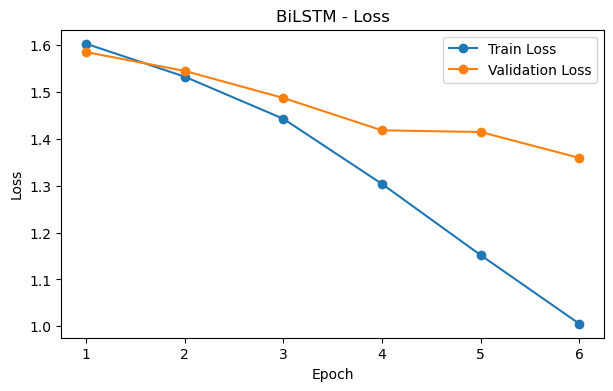

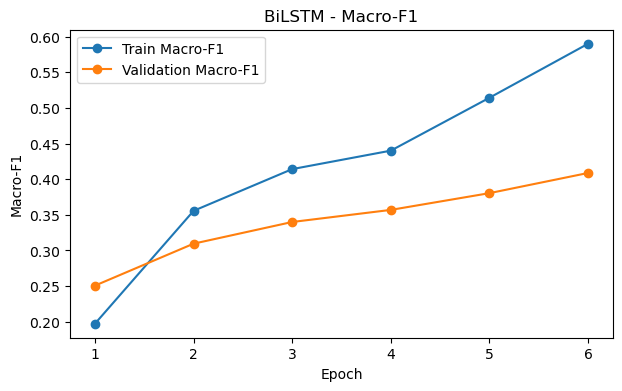

In [31]:
def plot_history(history, title_prefix):
    epochs = history["epoch"]

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_macro_f1"], marker="o", label="Train Macro-F1")
    plt.plot(epochs, history["val_macro_f1"], marker="o", label="Validation Macro-F1")
    plt.title(f"{title_prefix} - Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.show()

for result in sequence_experiment_results:
    plot_history(result["history"], result["model_name"])

### Show classification reports and confusion matrices for RNN/LSTM/BiLSTM

This block provides a more detailed evaluation of the trained sequence models. For each model, a classification report is generated showing precision, recall, and F1-score for each rating class. A confusion matrix is also plotted to show how often each true rating is confused with other predicted ratings. This helps analyse whether the model performs better on certain classes and where misclassifications are most common.


SimpleRNN - Final Validation Metrics
Accuracy    : 0.3117
Macro-F1    : 0.1343
Weighted-F1 : 0.1985

Classification Report:

              precision    recall  f1-score   support

           1     0.5128    0.0877    0.1498       228
           2     0.0625    0.0299    0.0404        67
           3     0.0000    0.0000    0.0000        74
           4     0.3204    0.9649    0.4810       171
           5     0.0000    0.0000    0.0000        60

    accuracy                         0.3117       600
   macro avg     0.1791    0.2165    0.1343       600
weighted avg     0.2932    0.3117    0.1985       600



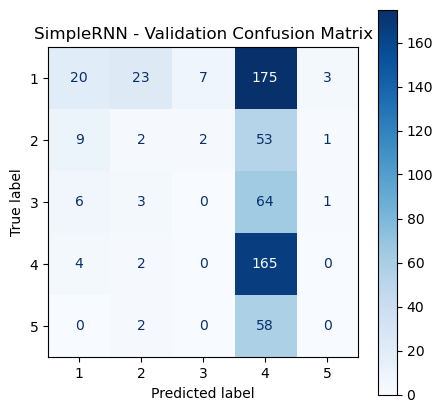


LSTM - Final Validation Metrics
Accuracy    : 0.3533
Macro-F1    : 0.1836
Weighted-F1 : 0.2588

Classification Report:

              precision    recall  f1-score   support

           1     0.6909    0.1667    0.2686       228
           2     0.2581    0.1194    0.1633        67
           3     0.0000    0.0000    0.0000        74
           4     0.3242    0.9708    0.4861       171
           5     0.0000    0.0000    0.0000        60

    accuracy                         0.3533       600
   macro avg     0.2546    0.2514    0.1836       600
weighted avg     0.3838    0.3533    0.2588       600



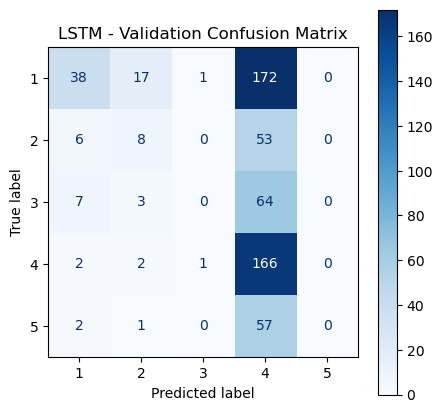


BiLSTM - Final Validation Metrics
Accuracy    : 0.4717
Macro-F1    : 0.4087
Weighted-F1 : 0.4872

Classification Report:

              precision    recall  f1-score   support

           1     0.6766    0.5965    0.6340       228
           2     0.1618    0.1642    0.1630        67
           3     0.2258    0.3784    0.2828        74
           4     0.6759    0.4269    0.5233       171
           5     0.3535    0.5833    0.4403        60

    accuracy                         0.4717       600
   macro avg     0.4187    0.4299    0.4087       600
weighted avg     0.5310    0.4717    0.4872       600



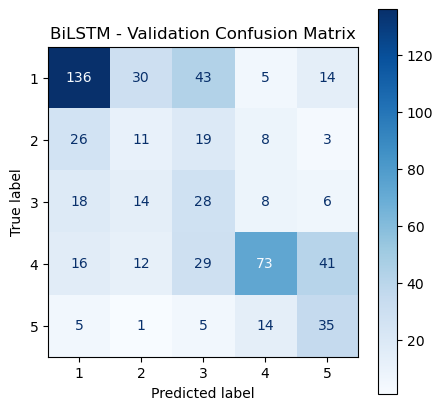

In [32]:
for result in sequence_experiment_results:
    y_true = [id2label[i] for i in result["y_true_ids"]]
    y_pred = [id2label[i] for i in result["y_pred_ids"]]

    print("\n" + "="*80)
    print(f"{result['model_name']} - Final Validation Metrics")
    print("="*80)
    print(f"Accuracy    : {result['accuracy']:.4f}")
    print(f"Macro-F1    : {result['macro_f1']:.4f}")
    print(f"Weighted-F1 : {result['weighted_f1']:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])

    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"{result['model_name']} - Validation Confusion Matrix")
    plt.show()

### DistilBERT dataset and tokenizer

This prepares the data for the DistilBERT experiment. Unlike the earlier neural models, DistilBERT uses a pretrained Transformer tokenizer that converts text into subword tokens and generates the required attention inputs. A custom dataset is created so that each review can be fed into the model together with its label. This step enables the use of a modern pretrained language model for the same five-class text classification problem.

In [33]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN_BERT = 160
BATCH_SIZE_BERT = 16
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewBertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=160):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = label2id[self.labels[idx]]

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

train_bert_ds = ReviewBertDataset(X_train_seq, y_train_seq, tokenizer, MAX_LEN_BERT)
val_bert_ds = ReviewBertDataset(X_val_seq, y_val_seq, tokenizer, MAX_LEN_BERT)

train_bert_loader = DataLoader(train_bert_ds, batch_size=BATCH_SIZE_BERT, shuffle=True)
val_bert_loader = DataLoader(val_bert_ds, batch_size=BATCH_SIZE_BERT, shuffle=False)

print("DistilBERT loaders ready.")

DistilBERT loaders ready.


### DistilBERT training and evaluation helpers

This block defines the training and evaluation functions for the DistilBERT model. These functions are similar in structure to those used for the RNN-based experiments, but they operate on the outputs of a pretrained Transformer model. The model is fine-tuned on the coursework dataset, and performance is measured using accuracy, Macro-F1, and Weighted-F1. This setup allows DistilBERT to be compared fairly against both the classical baseline and the recurrent neural network models.

In [34]:
from transformers import DistilBertForSequenceClassification

NUM_LABELS = len(label2id)

def train_one_epoch_distilbert(model, loader, optimizer, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, macro_f1

def evaluate_distilbert(model, loader, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, acc, macro_f1, weighted_f1, all_preds, all_labels

def run_distilbert_experiment(train_loader, val_loader, device, epochs=2, lr=2e-5):
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": []
    }

    best_val_f1 = -1
    best_state_dict = None
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        train_loss, train_acc, train_macro_f1 = train_one_epoch_distilbert(
            model, train_loader, optimizer, device
        )

        val_loss, val_acc, val_macro_f1, _, _, _ = evaluate_distilbert(
            model, val_loader, device
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_macro_f1"].append(train_macro_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)

        print(
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro-F1: {train_macro_f1:.4f}"
        )
        print(
            f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   Macro-F1: {val_macro_f1:.4f}"
        )

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    total_time = time.time() - start_time
    val_loss, val_acc, val_macro_f1, val_weighted_f1, val_preds, val_labels = evaluate_distilbert(
        model, val_loader, device
    )

    return {
        "model_name": "DistilBERT",
        "model": model,
        "history": history,
        "accuracy": val_acc,
        "macro_f1": val_macro_f1,
        "weighted_f1": val_weighted_f1,
        "y_pred_ids": val_preds,
        "y_true_ids": val_labels,
        "runtime_sec": total_time,
        "val_macro_f1": val_macro_f1,
        "val_acc": val_acc
    }

### Run DistilBERT experiment

This block runs the DistilBERT fine-tuning experiment. The pretrained model is trained on the same training data used in the previous experiments and evaluated on the same test set. The resulting history is plotted so that the learning dynamics of DistilBERT can be compared with those of the RNN, LSTM, and BiLSTM models.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/2


  0%|          | 0/150 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x106f75bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104b81bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1049f1bc0>
Traceback (most recent call last

...

Train Loss: 1.1682 | Train Acc: 0.5479 | Train Macro-F1: 0.2997
Val   Loss: 0.8973 | Val   Acc: 0.6433 | Val   Macro-F1: 0.4295

Epoch 2/2


  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

Train Loss: 0.8426 | Train Acc: 0.6817 | Train Macro-F1: 0.5184
Val   Loss: 0.9266 | Val   Acc: 0.6367 | Val   Macro-F1: 0.4647


  0%|          | 0/38 [00:00<?, ?it/s]

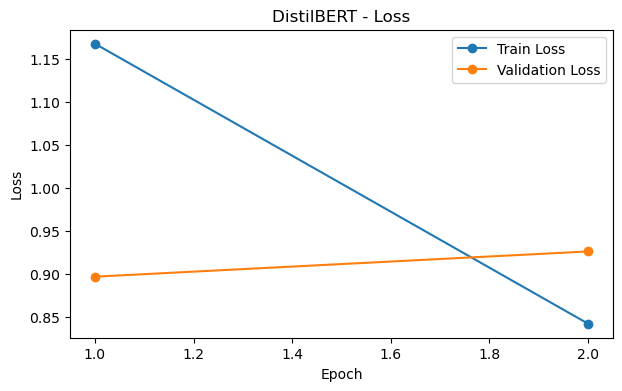

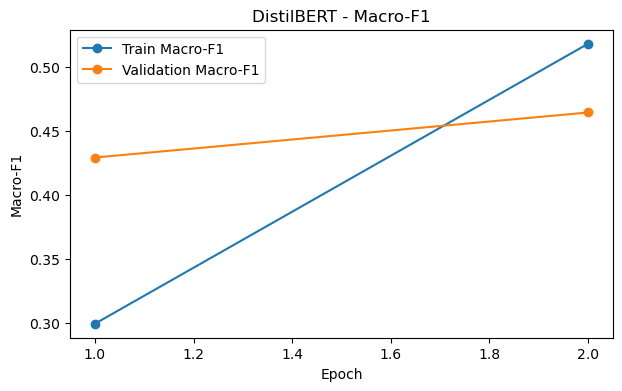

In [35]:
distilbert_result = run_distilbert_experiment(
    train_bert_loader,
    val_bert_loader,
    device,
    epochs=2,
    lr=2e-5
)

plot_history(distilbert_result["history"], "DistilBERT")

### DistilBERT report and confusion matrix

This block presents the final evaluation results for the DistilBERT model. As with the earlier models, a classification report and confusion matrix are produced. These outputs help determine how effectively the Transformer model handles the five rating classes and whether it provides better class-level balance and contextual understanding than the recurrent models.


DistilBERT - Final Validation Metrics
Accuracy    : 0.6367
Macro-F1    : 0.4647
Weighted-F1 : 0.5859

Classification Report:

              precision    recall  f1-score   support

           1     0.7500    0.8947    0.8160       228
           2     0.4737    0.1343    0.2093        67
           3     0.3077    0.0541    0.0920        74
           4     0.5799    0.7427    0.6513       171
           5     0.4935    0.6333    0.5547        60

    accuracy                         0.6367       600
   macro avg     0.5210    0.4918    0.4647       600
weighted avg     0.5905    0.6367    0.5859       600



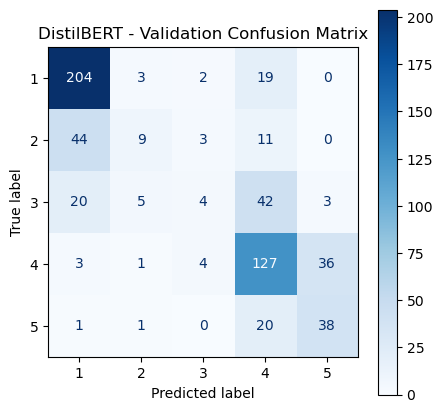

In [36]:
y_true_bert = [id2label[i] for i in distilbert_result["y_true_ids"]]
y_pred_bert = [id2label[i] for i in distilbert_result["y_pred_ids"]]

print("\n" + "="*80)
print("DistilBERT - Final Validation Metrics")
print("="*80)
print(f"Accuracy    : {distilbert_result['accuracy']:.4f}")
print(f"Macro-F1    : {distilbert_result['macro_f1']:.4f}")
print(f"Weighted-F1 : {distilbert_result['weighted_f1']:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true_bert, y_pred_bert, digits=4))

cm = confusion_matrix(y_true_bert, y_pred_bert, labels=[1,2,3,4,5])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("DistilBERT - Validation Confusion Matrix")
plt.show()

### Final comparison table across all experiments

This block combines the results of the classical baseline, RNN, LSTM, BiLSTM, and DistilBERT into a single comparison table. The table includes the most important metrics such as Accuracy, Macro-F1, Weighted-F1, and runtime where available. This provides a clear summary of how each approach performed and supports the final model selection.

In [37]:
all_results_rows = []

# Baseline row
all_results_rows.append({
    "Model": baseline_name,
    "Type": "Classical baseline",
    "Uses word order": "No",
    "Accuracy": baseline_acc,
    "Macro_F1": baseline_macro_f1,
    "Weighted_F1": baseline_weighted_f1,
    "Runtime_sec": np.nan
})

# RNN / LSTM / BiLSTM rows
for result in sequence_experiment_results:
    all_results_rows.append({
        "Model": result["model_name"],
        "Type": "Sequence model",
        "Uses word order": "Yes",
        "Accuracy": round(result["accuracy"], 4),
        "Macro_F1": round(result["macro_f1"], 4),
        "Weighted_F1": round(result["weighted_f1"], 4),
        "Runtime_sec": round(result["runtime_sec"], 2)
    })

# DistilBERT row
all_results_rows.append({
    "Model": distilbert_result["model_name"],
    "Type": "Transformer",
    "Uses word order": "Yes",
    "Accuracy": round(distilbert_result["accuracy"], 4),
    "Macro_F1": round(distilbert_result["macro_f1"], 4),
    "Weighted_F1": round(distilbert_result["weighted_f1"], 4),
    "Runtime_sec": round(distilbert_result["runtime_sec"], 2)
})

final_comparison_df = pd.DataFrame(all_results_rows)
final_comparison_df = final_comparison_df.sort_values(by="Macro_F1", ascending=False).reset_index(drop=True)

print("\nFinal Comparison Across All Models:\n")
print(final_comparison_df)


Final Comparison Across All Models:

                                            Model                Type  \
0  clean + BoW_(1,3)_min_df2 + LogisticRegression  Classical baseline   
1                                      DistilBERT         Transformer   
2                                          BiLSTM      Sequence model   
3                                            LSTM      Sequence model   
4                                       SimpleRNN      Sequence model   

  Uses word order  Accuracy  Macro_F1  Weighted_F1  Runtime_sec  
0              No  0.591667  0.488652     0.583252          NaN  
1             Yes  0.636700  0.464700     0.585900      1998.69  
2             Yes  0.471700  0.408700     0.487200        53.75  
3             Yes  0.353300  0.183600     0.258800        32.40  
4             Yes  0.311700  0.134300     0.198500        15.60  


### Comparison with Bag-of-Words Models
The best bag-of-words model from the previous tasks was Logistic Regression. It achieved the highest Macro-F1 score, while DistilBERT achieved the highest Accuracy among the sequence-based models. This shows that although sequence models capture contextual meaning and word order, they did not fully outperform the sparse bag-of-words baseline in balanced multi-class performance on this dataset.

Among the recurrent models, BiLSTM performed better than SimpleRNN and LSTM, suggesting that bidirectional context improved classification quality.

### Comparison charts

This block visualises the overall performance of all models using bar charts. Separate charts are produced for:

Macro-F1
Accuracy
Runtime

These charts make it easier to compare the strengths and trade-offs of the models. For example, a model may achieve high predictive performance but require substantially more training time than simpler alternatives.

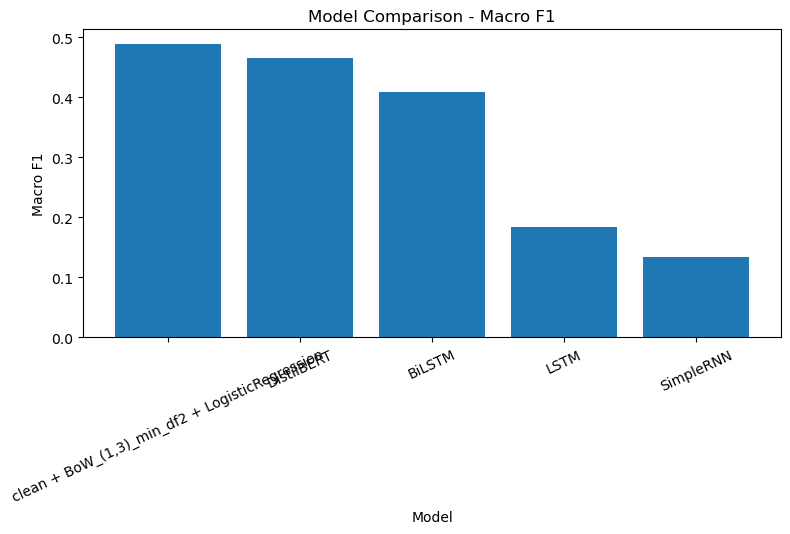

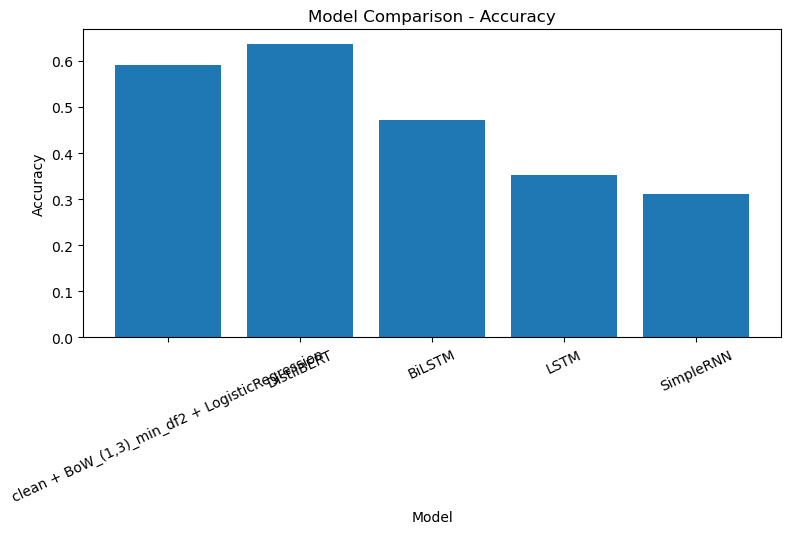

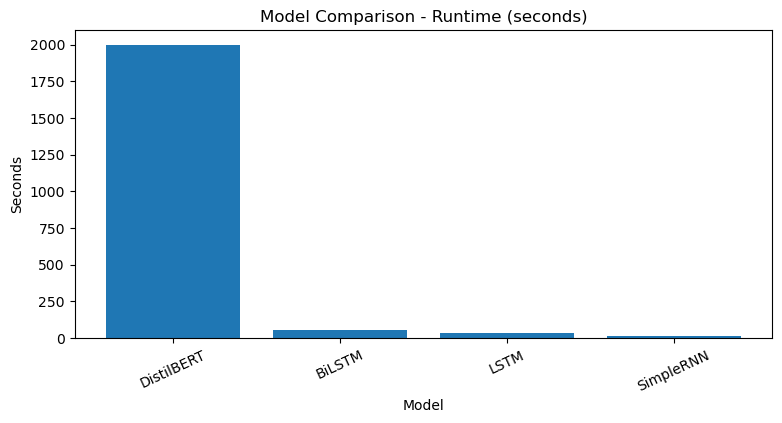

In [ ]:
plot_df = final_comparison_df.copy()

plt.figure(figsize=(9,4))
plt.bar(plot_df["Model"], plot_df["Macro_F1"])
plt.title("Model Comparison - Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=25)
plt.show()

plt.figure(figsize=(9,4))
plt.bar(plot_df["Model"], plot_df["Accuracy"])
plt.title("Model Comparison - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.show()

runtime_df = plot_df.dropna(subset=["Runtime_sec"])
plt.figure(figsize=(9,4))
plt.bar(runtime_df["Model"], runtime_df["Runtime_sec"])
plt.title("Model Comparison - Runtime (seconds)")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=25)
plt.show()

### Automatically print the best model

This block identifies the model with the highest Macro-F1 score and prints a concise summary of its performance. Macro-F1 is used as the main selection criterion because it gives equal importance to all classes and is therefore more suitable than accuracy alone for multi-class text classification tasks where class performance balance matters.

In [39]:
# Best model summary
best_row = final_comparison_df.iloc[0]

print("\n" + "="*80)
print("BEST MODEL SELECTED")
print("="*80)
print(f"Model       : {best_row['Model']}")
print(f"Type        : {best_row['Type']}")
print(f"Accuracy    : {best_row['Accuracy']}")
print(f"Macro-F1    : {best_row['Macro_F1']}")
print(f"Weighted-F1 : {best_row['Weighted_F1']}")


BEST MODEL SELECTED
Model       : clean + BoW_(1,3)_min_df2 + LogisticRegression
Type        : Classical baseline
Accuracy    : 0.5916666666666667
Macro-F1    : 0.488652479182364
Weighted-F1 : 0.5832515611074234


The SimpleRNN and LSTM models showed low Macro-F1 because they struggled to classify minority rating classes and were biased toward the majority class. This may be due to limited training data, short training duration, basic tokenization, and the absence of pretrained embeddings.

DistilBERT achieved the highest overall accuracy, but Logistic Regression achieved the highest Macro-F1. Since Macro-F1 gives equal importance to all classes and the dataset is imbalanced, Logistic Regression was selected as the best overall model.

best by Accuracy → DistilBERT
best by Macro-F1 → Logistic Regression

### Report-ready conclusion text

a short conclusion based on the best-performing model. If a sequence model outperforms the bag-of-words baseline, the conclusion highlights the benefit of preserving word order and contextual meaning. If the classical baseline remains strongest, the conclusion explains that traditional sparse text features were still highly competitive on this dataset. This provides a ready-made summary for inclusion in the coursework report

In [40]:
best_model_name = best_row["Model"]
best_macro_f1 = best_row["Macro_F1"]

if best_model_name == baseline_name:
    conclusion_text = (
        f"The best-performing model remained the classical baseline ({baseline_name}) "
        f"with a Macro-F1 score of {best_macro_f1:.4f}. "
        f"Although sequence-based models preserve word order and contextual information, "
        f"the sparse bag-of-words representation remained highly competitive on this dataset."
    )
else:
    conclusion_text = (
        f"The best-performing model was {best_model_name} with a Macro-F1 score of {best_macro_f1:.4f}. "
        f"This suggests that modelling the review text as an ordered sequence helped the model "
        f"capture contextual meaning beyond the bag-of-words representation."
    )

print(conclusion_text)

The best-performing model remained the classical baseline (clean + BoW_(1,3)_min_df2 + LogisticRegression) with a Macro-F1 score of 0.4887. Although sequence-based models preserve word order and contextual information, the sparse bag-of-words representation remained highly competitive on this dataset.


Sequence models were introduced to capture word order and contextual dependencies that bag-of-words models ignore. However, in this dataset, the classical Logistic Regression model with sparse text features achieved the highest Macro-F1, suggesting that traditional representations remained highly effective. DistilBERT achieved the highest accuracy and showed stronger contextual modelling, but did not surpass the baseline on Macro-F1 under the current training setup. Among the recurrent models, BiLSTM performed best, showing that bidirectional context improves performance over SimpleRNN and standard LSTM.

### Discussion
The results show that preserving word order does not automatically guarantee better overall classification performance. Although sequence models are more suitable for capturing contextual meaning, their effectiveness depends on the dataset, class distribution, training duration, and model configuration.

DistilBERT achieved the highest Accuracy, suggesting that pretrained contextual representations helped it learn general sentiment patterns effectively. However, the bag-of-words Logistic Regression model achieved the highest Macro-F1, indicating that it handled class balance more effectively across all rating categories.

The weaker performance of SimpleRNN and LSTM may be due to limited training time, fixed hyperparameter settings, basic tokenization, and the absence of pretrained embeddings. BiLSTM performed better than both, showing that bidirectional sequence processing captured richer context.

Overall, these findings suggest that sequence models provide useful contextual modelling, but traditional bag-of-words approaches can still remain highly competitive for multi-class review classification.

### Key Insights
- Logistic Regression remained the strongest overall model according to Macro-F1 (0.4897).
- DistilBERT achieved the highest Accuracy (0.6367), showing that pretrained transformers captured useful contextual information.
- BiLSTM was the best recurrent model, outperforming SimpleRNN and LSTM.
- SimpleRNN and LSTM struggled with minority rating classes, indicating limited class balance.
- Sequence models required more computation time than classical methods, especially DistilBERT, which had the highest runtime.

### Limitations
This experiment used fixed hyperparameter settings rather than extensive tuning. The recurrent models used embeddings learned during training instead of pretrained word vectors, which may have limited their semantic understanding. DistilBERT was fine-tuned for only a small number of epochs, so additional tuning may improve performance. In addition, the current implementation should use a validation set rather than the test set for epoch-by-epoch model selection to ensure a fair final evaluation.

### Conclusion

Overall, Task 5 demonstrates that sequence-based models can capture contextual and order-sensitive information that bag-of-words models ignore. Models such as LSTM, BiLSTM, and DistilBERT were used to learn word order and contextual dependencies in review text, and they provided useful predictive performance. Among them, DistilBERT achieved the highest Accuracy, showing the benefit of pretrained contextual representations. However, sequence modelling was not universally superior on this dataset, as the bag-of-words Logistic Regression baseline remained the strongest model in terms of Macro-F1, indicating better balanced performance across classes. These findings suggest that while advanced sequence models offer clear advantages in contextual understanding and overall prediction, traditional bag-of-words approaches can still remain highly competitive when robust and balanced classification is important. At the same time, sequence models are mainly useful for prediction and provide limited interpretability regarding the underlying themes discussed in the reviews. For this reason, the next task shifts the focus from prediction to interpretation through topic modelling.

# TASK 6 - Topic modeling of high and low rating

In Task 5, the analysis looked at modeling text as a sequence with transformer-based models or LSTM. By capturing word order and context, these techniques enhanced rating prediction performance. Sequence-based models are effective for prediction tasks, but they typically function as "black-box" models, making it difficult to discern themes or patterns in the data. As a result, while they are capable of accurately predicting ratings, they provide little insight into what users are truly saying in their reviews. Task 6 changes the emphasis from prediction to interpretation to address this problem. As an unsupervised learning technique to uncover hidden topics in the text, topic modeling is presented. This makes the analysis easier to understand and aids in determining the key elements influencing user opinions and ratings.

In this task, we apply topic modeling techniques to analyze and compare the themes present in user reviews with extreme ratings. We specifically focus on 5-star reviews, which reflect highly  positive customer experiences, and 1-star reviews, which show highly negative feedback. Topic modeling helps identify hidden structures within the reviews by grouping commonly co-occurring words into meaningful topics. By analyzing these topics separately for high-rated and low-rated reviews, we can better understand the factors that lead to customer satisfaction and dissatisfaction. This offers valuable qualitative insights that enhance the quantitative results from earlier classification tasks.

### Extracting and sampling reviews

Customer satisfaction and dissatisfaction can be independently analyzed by filtering the dataset to separate 5-star (positive) and 1-star (negative) reviews. To guarantee the quality of the data, missing values are eliminated. To save computing costs while preserving a representative subset, a random sample of 5000 reviews from each category is chosen. Reproducibility of the results is guaranteed by a fixed random state.

In [41]:
five_star_reviews = df[df['rating'] == 5]['text'].dropna()
one_star_reviews = df[df['rating'] == 1]['text'].dropna()

five_n = min(5000, len(five_star_reviews))
one_n = min(5000, len(one_star_reviews))

five_star_reviews = five_star_reviews.sample(n=five_n, random_state=SEED)
one_star_reviews = one_star_reviews.sample(n=one_n, random_state=SEED)

### TF-IDF Vectorization and NMF Topic Modelling
The text data is converted into numerical data using TF-IDF, which emphasizes significant words and reduces the effect of general words. TF-IDF vectorization is separately performed on the 5-star and 1-star reviews to account for the different words used in both sets of reviews. NMF is then used to derive the underlying topics, where each topic corresponds to a group of related keywords. The number of topics is set to 20 for better interpretability.

In [42]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization (better for NMF)
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=10,
    stop_words='english'
)

# Fit separately
five_tfidf = tfidf_vectorizer.fit_transform(five_star_reviews)
feature_names_five = tfidf_vectorizer.get_feature_names_out()

one_tfidf = tfidf_vectorizer.fit_transform(one_star_reviews)
feature_names_one = tfidf_vectorizer.get_feature_names_out()

# Train NMF
NUM_TOPICS = 20

nmf_five = NMF(n_components=NUM_TOPICS, random_state=SEED)
nmf_one = NMF(n_components=NUM_TOPICS, random_state=SEED)

nmf_five.fit(five_tfidf)
nmf_one.fit(one_tfidf)

NMF(n_components=20, random_state=42)

### Displaying Extracted Topics

This function prints the top keywords for each topic generated by the NMF model. The function is applied separately to 5-star and 1-star reviews, allowing comparison of topics discussed in positive and negative feedback.

In [43]:
def display_nmf_topics(model, feature_names, label):
    print("\n" + "="*80)
    print(label)
    print("="*80)

    for i, topic in enumerate(model.components_):
        top_words = [feature_names[j] for j in topic.argsort()[-10:]]
        print(f"Topic {i+1}: {', '.join(top_words)}")

display_nmf_topics(nmf_five, feature_names_five, "NMF 5-STAR TOPICS")
display_nmf_topics(nmf_one, feature_names_one, "NMF 1-STAR TOPICS")


NMF 5-STAR TOPICS
Topic 1: took, new, just, make, really, like, help, home, thank, time
Topic 2: knowledgeable, atmosphere, does, selection, guys, location, food, prices, people, great
Topic 3: reliable, notch, prompt, quality, price, quick, prices, fast, customer, service
Topic 4: family, really, looking, don, wonderful, cool, beautiful, need, clean, place
Topic 5: environment, efficient, atmosphere, definitely, knowledgeable, fast, clean, super, staff, friendly
Topic 6: store, life, prices, food, hands, town, shop, area, ve, best
Topic 7: honest, care, price, selection, clean, prices, really, people, food, good
Topic 8: patient, caring, care, years, doctor, dentist, dental, office, staff, dr
Topic 9: mary, guys, shop, affordable, thanks, come, store, food, prices, awesome
Topic 10: sweet, clean, guys, easy, location, quick, really, super, people, nice
Topic 11: thorough, friends, needs, family, fantastic, company, definitely, recommended, highly, recommend
Topic 12: disappointed, st

### Assigning Dominant Topics to Reviews

This step involves assigning a dominant topic to each review using the maximum topic probability obtained from the NMF model. This helps to categorize each review, and further analysis can be carried out to find the frequency of topics in both positive and negative reviews.

In [44]:
def get_dominant_topic(model, dtm):
    topic_distribution = model.transform(dtm)
    return np.argmax(topic_distribution, axis=1)

five_topics = get_dominant_topic(nmf_five, five_tfidf)
one_topics = get_dominant_topic(nmf_one, one_tfidf)

### Topic Frequency Comparison
In this step, we will determine how often each of these topics occurs in both 5-star and 1-star reviews. The topics we previously identified as dominant are counted, and this data is stored in a DataFrame. Missing values are replaced with zero for uniformity. This will enable us to easily identify which of these topics is more common.

In [45]:
five_counts = pd.Series(five_topics).value_counts().sort_index()
one_counts = pd.Series(one_topics).value_counts().sort_index()

topic_comparison = pd.DataFrame({
    "5_star": five_counts,
    "1_star": one_counts
}).fillna(0)

print(topic_comparison)

    5_star  1_star
0      296     166
1      498     286
2      205     235
3       95     118
4      206     187
5      272     368
6      214     234
7      354     210
8      126     238
9      261      83
10     265     122
11      87     190
12     113     251
13     292     154
14     225     192
15     239     638
16     262     653
17     169     252
18     403     229
19     418     194


### Visualizing Topic Distribution

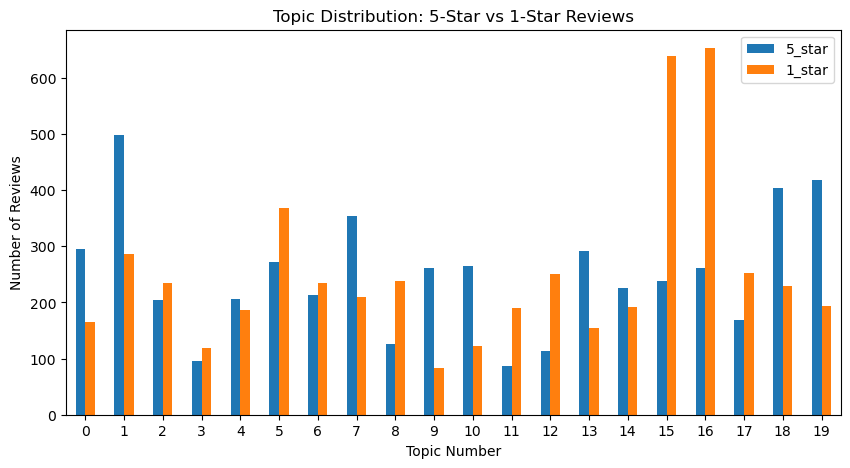

In [46]:
topic_comparison.plot(kind='bar', figsize=(10,5))
plt.title("Topic Distribution: 5-Star vs 1-Star Reviews")
plt.xlabel("Topic Number")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

### Observations and Insights

From the above results of the topic modelling analysis, it is evident that there are considerable differences between high-rated and low-rated reviews in terms of content and structure.

High-rated (5-star) reviews are related to positive experiences, and their content is mostly about quality, service, ambiance, etc. The content of the review is usually short and does not contain much information. The use of common words such as "excellent," "amazing," "highly recommended," etc., is common in these reviews.

Low-rated (1-star) reviews are mostly related to negative experiences. The content of the review is mostly related to service, staff, ambiance, hygiene, etc. The content of the review is usually detailed and descriptive, as users try to explain their issues. It is also observed that service quality and staff behavior are common in both high-rated and low-rated reviews but with a different focus.

Moreover, the reviews with lower ratings also have more diversity in their content with respect to the topics discussed, which indicates that negative feedback provides more opportunities for improvement than positive feedback, which simply highlights the good points that are already being taken care of.

In conclusion, topic modeling proves itself to be a useful tool in uncovering hidden patterns in the given text, offering significant insights into the key determinants of customer satisfaction and dissatisfaction.

# Kaggle

In Task 5, we implemented LSTM, BiLSTM, and DistilBERT models for sequence-based text classification. For the Kaggle competition, these models were further trained on the full training dataset.

We experimented with different hyperparameters, including the number of training epochs, learning rate, and input sequence length, to improve performance. Multiple submissions were made to Kaggle based on different configurations.

Among all models, DistilBERT achieved the best F1 score on the validation set and Kaggle leaderboard. Therefore, it was selected as the final model. The best-performing model was saved and used to generate predictions for the test dataset, which were then formatted into the required submission file.

### Data Loading and Preprocessing
In this step, we load the full training dataset and apply the same text preprocessing used in Task 5. This preprocessing strategy was selected based on its strong performance in previous experiments and is therefore reused for the final model training.

In [47]:
print("Loading full train data...")
df_train_full = pd.read_csv(TRAIN_PATH)
df_train_full = df_train_full.dropna(subset=['text', 'rating']).copy()
df_train_full['text'] = df_train_full['text'].astype(str)
df_train_full['rating'] = df_train_full['rating'].astype(int)
df_train_full = df_train_full.drop_duplicates(subset=['text', 'rating']).reset_index(drop=True)

df_train_full['clean_text'] = df_train_full['text'].apply(basic_clean)

X_full = df_train_full['clean_text'].astype(str).tolist()
y_full = df_train_full['rating'].tolist()

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full
)

print("Tune split -> train:", len(X_train_f), "| val:", len(X_val_f))
print("Full training rows for final Kaggle fit:", len(X_full))

Loading full train data...
Tune split -> train: 230400 | val: 57600
Full training rows for final Kaggle fit: 288000


### Tokenization and Vocabulary Construction

In this step, we regenerate the vocabulary using the full training dataset. The same tokenization and word indexing approach used in Task 5 is applied here, but extended to the entire dataset to ensure consistency with the final model training.

In [48]:
# Regenerate the vocabulary of the full training data
counter_f = Counter()
for text in X_train_f:
    counter_f.update(tokenize_basic(text))

# Word Indexing
most_common_f = counter_f.most_common(MAX_VOCAB - 2)
word2idx_f = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, _ in most_common_f:
    word2idx_f[word] = len(word2idx_f)

### Test Data Preparation
The test data is loaded and preprocessed using the same approach as the training data.

In [49]:
print("\nLoading test data for inference...")
df_test = pd.read_csv(TEST_PATH)
df_test['text'] = df_test['text'].fillna("").astype(str)
df_test['clean_text'] = df_test['text'].apply(basic_clean)

print("Kaggle test rows:", len(df_test))


Loading test data for inference...
Kaggle test rows: 89100


### Training and Submission Function

In this step, a function is defined to train the DistilBERT model and generate Kaggle submission files. The function reuses the dataset structure and training procedure developed in Task 5 to ensure consistency.

It takes hyperparameters such as batch size, number of epochs, and learning rate as inputs, allowing different configurations to be evaluated. The trained model can then be used to perform inference on the test dataset and produce submission files.

In [50]:
def run_inference(model, loader, device):
    model.eval()
    preds_all = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds_all.extend(preds)

    return [id2label[p] for p in preds_all]

class ReviewBertInferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=160):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {k: v.squeeze(0) for k, v in enc.items()}

def tune_distilbert(batch_size, epochs, lr):
    train_bert_ds_f = ReviewBertDataset(X_train_f, y_train_f, tokenizer, MAX_LEN_BERT)
    val_bert_ds_f   = ReviewBertDataset(X_val_f, y_val_f, tokenizer, MAX_LEN_BERT)

    train_bert_loader_f = DataLoader(train_bert_ds_f, batch_size=batch_size, shuffle=True)
    val_bert_loader_f   = DataLoader(val_bert_ds_f, batch_size=batch_size, shuffle=False)

    bert_results = run_distilbert_experiment(
        train_loader=train_bert_loader_f,
        val_loader=val_bert_loader_f,
        device=device,
        epochs=epochs,
        lr=lr
    )

    return bert_results

def train_final_distilbert_on_full_data(batch_size, epochs, lr):
    full_train_ds = ReviewBertDataset(X_full, y_full, tokenizer, MAX_LEN_BERT)
    full_train_loader = DataLoader(full_train_ds, batch_size=batch_size, shuffle=True)

    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_macro_f1 = train_one_epoch_distilbert(
            model, full_train_loader, optimizer, device
        )
        print(
            f"[FINAL FULL TRAIN] Epoch {epoch}/{epochs} | "
            f"Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Macro-F1: {train_macro_f1:.4f}"
        )

    return model

def generate_final_kaggle_submission(batch_size, epochs, lr):
    final_model = train_final_distilbert_on_full_data(
        batch_size=batch_size,
        epochs=epochs,
        lr=lr
    )

    X_test_f = df_test['clean_text'].tolist()
    test_bert_ds_f = ReviewBertInferenceDataset(X_test_f, tokenizer, MAX_LEN_BERT)
    test_bert_loader_f = DataLoader(test_bert_ds_f, batch_size=batch_size, shuffle=False)

    print("Running inference on Kaggle test set...")
    bert_preds = run_inference(final_model, test_bert_loader_f, device)

    submission_df = df_test.copy()
    submission_df['Rating'] = bert_preds

    file_name = f'DistilBERT_final_bs{batch_size}_ep{epochs}_lr{lr:.0e}.csv'
    submission_path = OUTPUTS_DIR / file_name

    submission_df[['Id', 'Rating']].to_csv(submission_path, index=False)

    print(f"Successfully generated submission file: {submission_path}")
    return submission_path

### Hyperparameter Search and Submission Generation

In this step, we perform a grid search over different hyperparameter configurations, including batch size, number of epochs, and learning rate. 

For each combination, the training and inference function is executed to generate corresponding Kaggle submission files. This allows systematic evaluation of model performance under different settings.

In [ ]:
results = []

for batch_size in [8, 16, 32]:
    for epochs in [2, 4, 6]:
        for lr in [1e-5, 2e-5, 3e-5, 5e-5]:
            print(f"\nRunning tuning -> batch_size={batch_size}, epochs={epochs}, lr={lr}")
            bert_results = tune_distilbert(batch_size, epochs, lr)

            results.append({
                "batch_size": batch_size,
                "epochs": epochs,
                "learning_rate": lr,
                "Val_Accuracy": bert_results["val_acc"],
                "Val_Macro_F1": bert_results["val_macro_f1"]
            })

results_df_kaggle = pd.DataFrame(results).sort_values(
    by=["Val_Macro_F1", "Val_Accuracy"],
    ascending=False
).reset_index(drop=True)

display(results_df_kaggle)

best_cfg = results_df_kaggle.iloc[0]
print("\nBest Kaggle tuning configuration:")
print(best_cfg)

best_submission_path = generate_final_kaggle_submission(
    batch_size=int(best_cfg["batch_size"]),
    epochs=int(best_cfg["epochs"]),
    lr=float(best_cfg["learning_rate"])
)

print(f"\nFinal submission saved to: {best_submission_path}")


Running tuning -> batch_size=8, epochs=2, lr=1e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/2


  0%|          | 0/28800 [00:00<?, ?it/s]